# Clustering


### Generate data

In [1]:
# Importing all necessary libraries 
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
# Adding the code from the task 
n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation) # Anisotropic blobs
X_varied, y_varied = make_blobs(
n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state) # Unequal variance
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])) # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

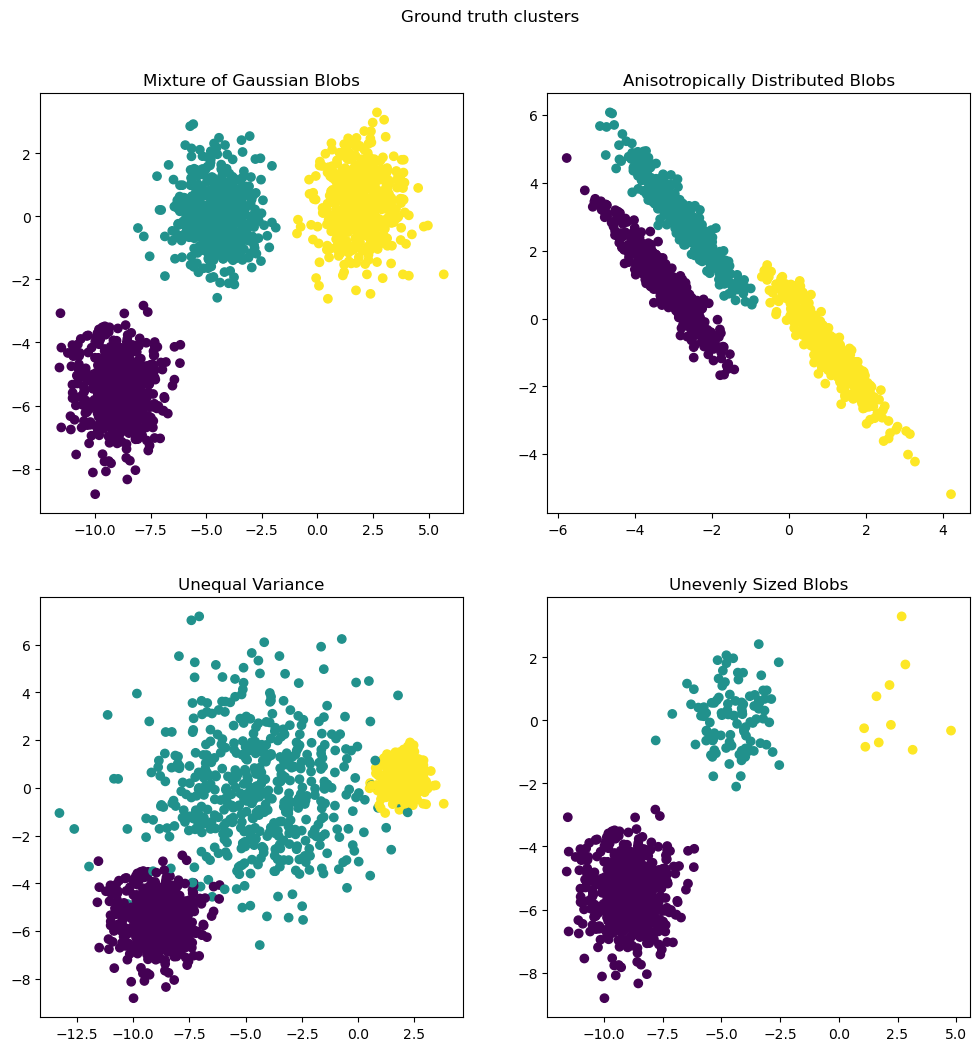

In [3]:
# Visualization (the plot showing the data and cluster identities)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)

axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

### Lloyd’s algorithm


In [4]:
def kmeans_lloyd(X, k, max_iter=200, tol=1e-6, random_state=0):
    """
    Lloyd's algorithm (k-means) with random init from data.
    Returns: centers (k,d), labels (n,), objective (float)
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    # init: choosing k distinct points
    init_idx = rng.choice(n, size=k, replace=False)
    centers = X[init_idx].copy()

    labels = None

    for _ in range(max_iter):
        # Assignment step
        dists2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        new_labels = dists2.argmin(axis=1)

        # Updating step
        new_centers = centers.copy()
        for j in range(k):
            mask = (new_labels == j)
            if np.any(mask):
                new_centers[j] = X[mask].mean(axis=0)
            else:
                # empty cluster -> reset to random point
                new_centers[j] = X[rng.integers(n)]

        # Checking Convergence
        if labels is not None and np.array_equal(new_labels, labels):
            centers = new_centers
            labels = new_labels
            break

        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        labels = new_labels
        if shift < tol:
            break

    # Objective
    final_dists2 = ((X - centers[labels]) ** 2).sum(axis=1)
    objective = final_dists2.sum()

    return centers, labels, objective


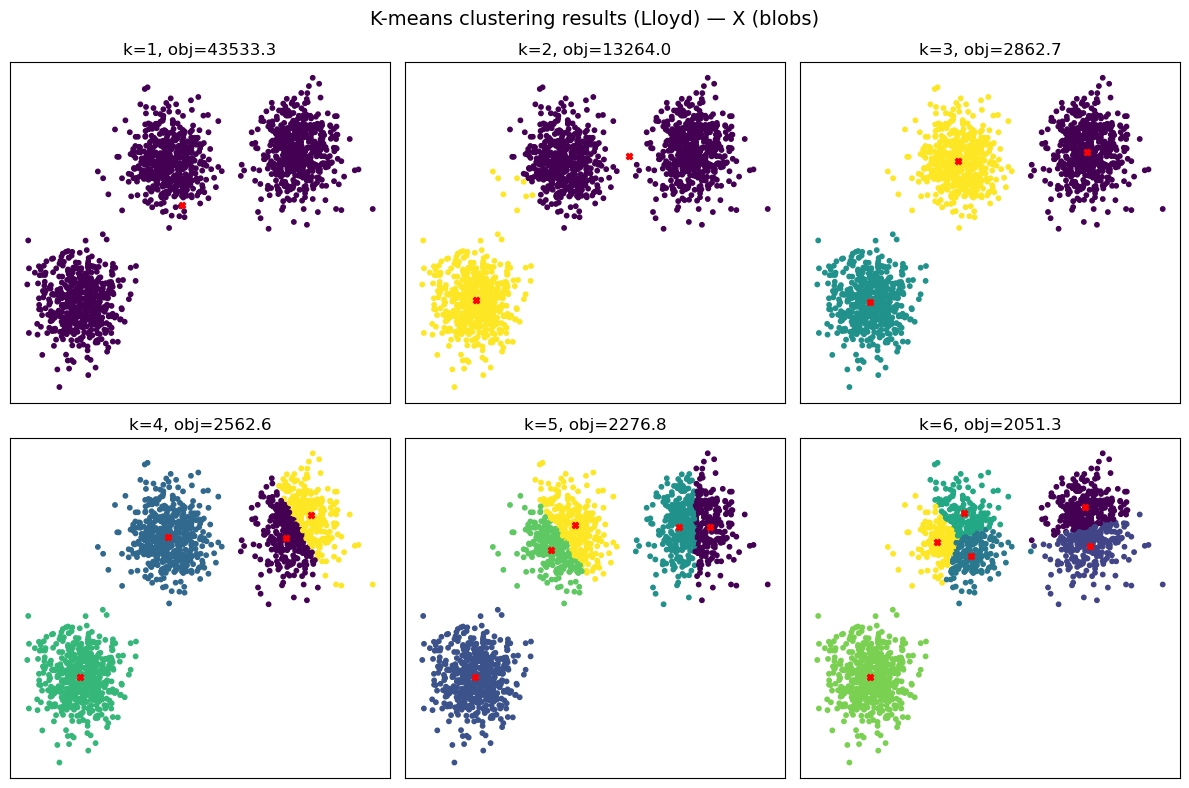

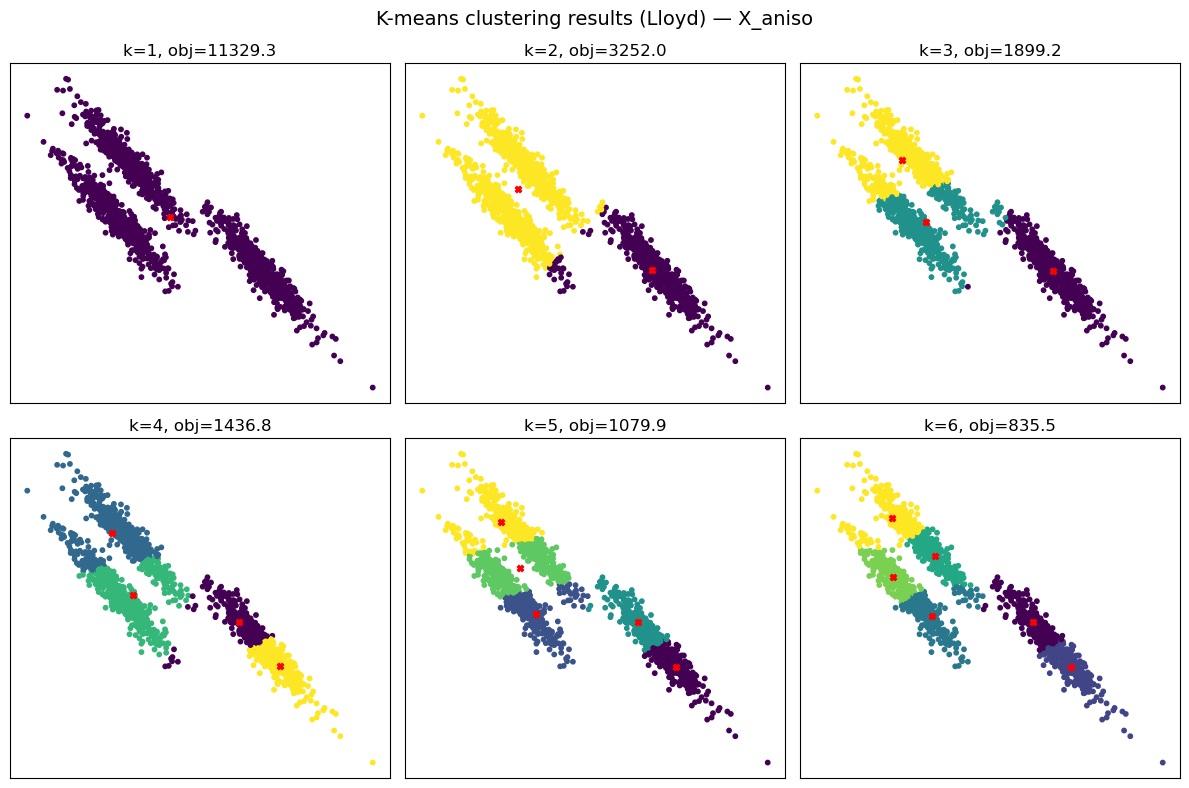

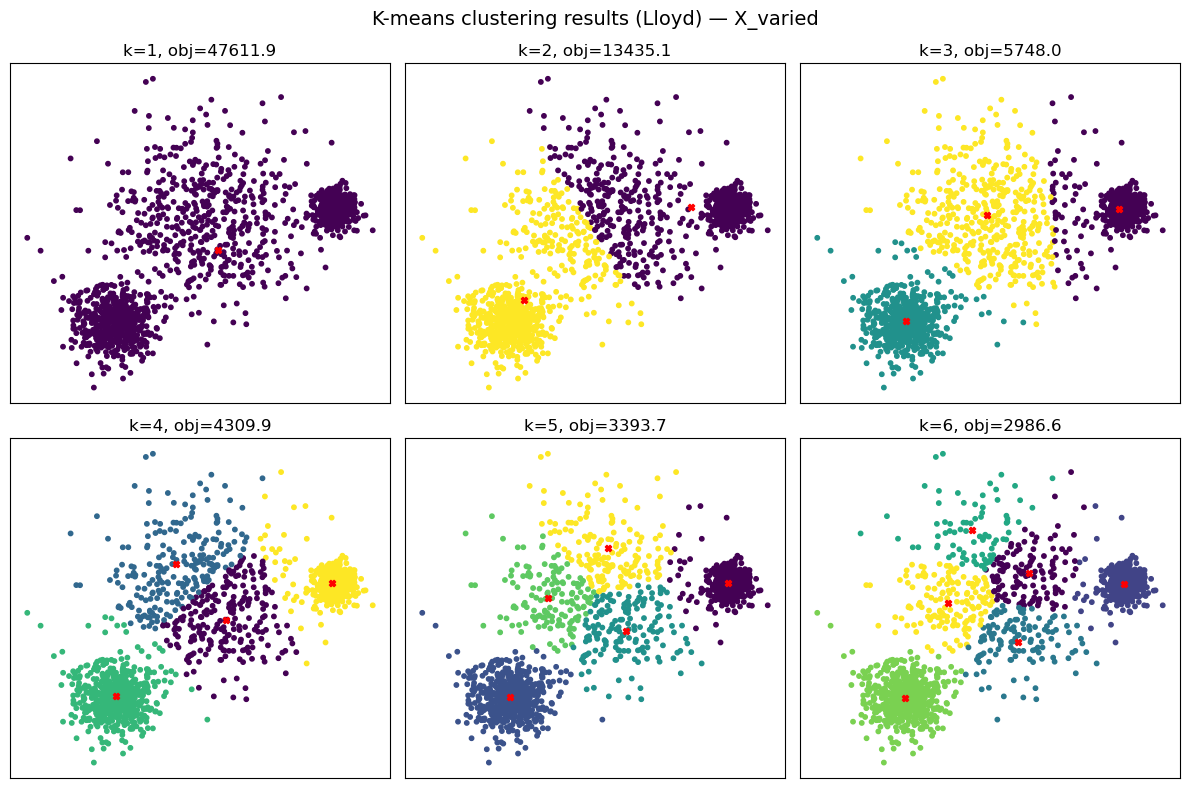

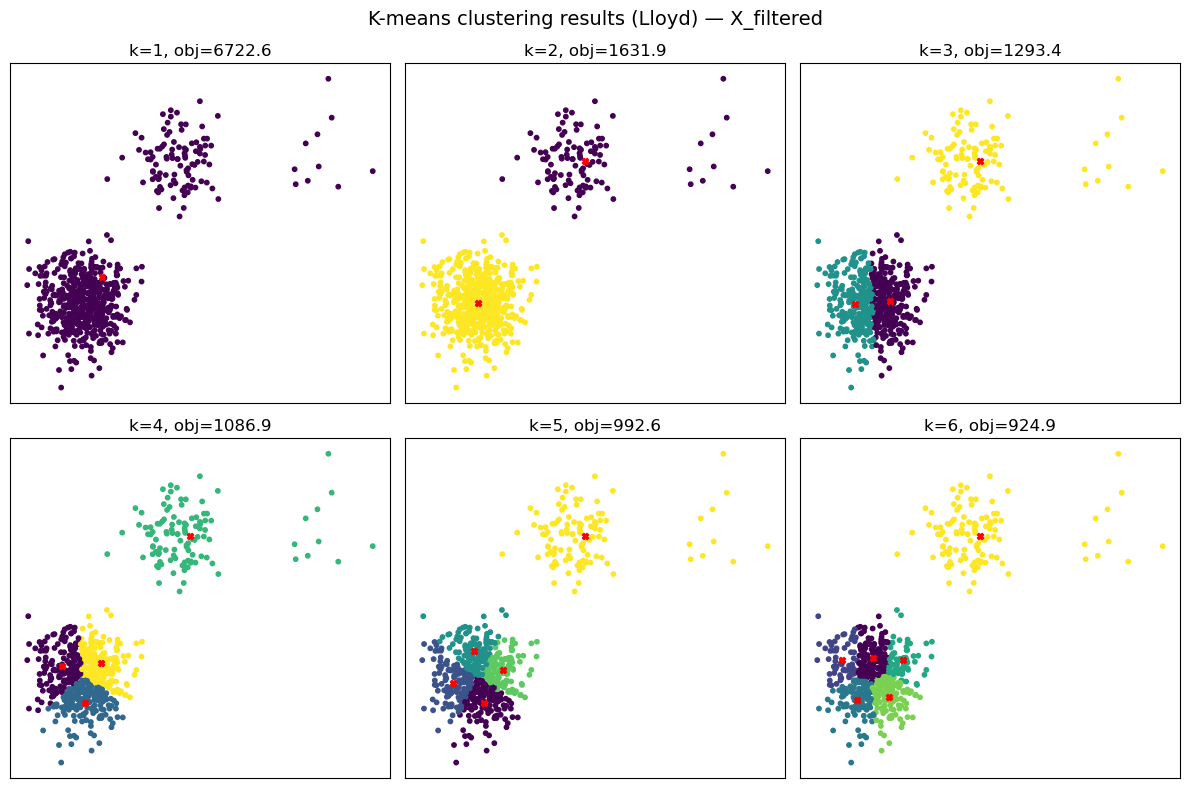

In [5]:
datasets = {
    "X (blobs)": X,
    "X_aniso": X_aniso,
    "X_varied": X_varied,
    "X_filtered": X_filtered
}

ks = [1, 2, 3, 4, 5, 6]
random_state = 0

for name, data in datasets.items():
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for idx, k in enumerate(ks):
        centers, labels, obj = kmeans_lloyd(data, k, random_state=random_state)

        ax = axes[idx]
        ax.scatter(data[:, 0], data[:, 1], c=labels, s=10)
        ax.scatter(centers[:, 0], centers[:, 1], marker="X", s=20, color = 'red')
        ax.set_title(f"k={k}, obj={obj:.1f}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"K-means clustering results (Lloyd) — {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

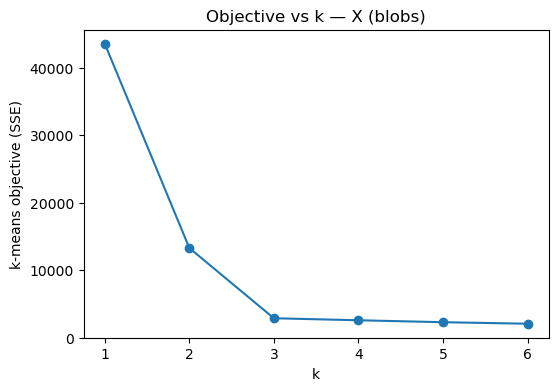

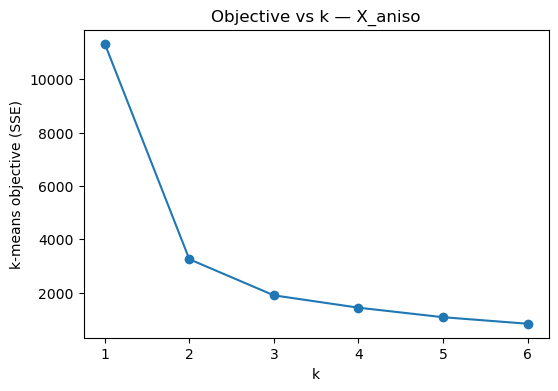

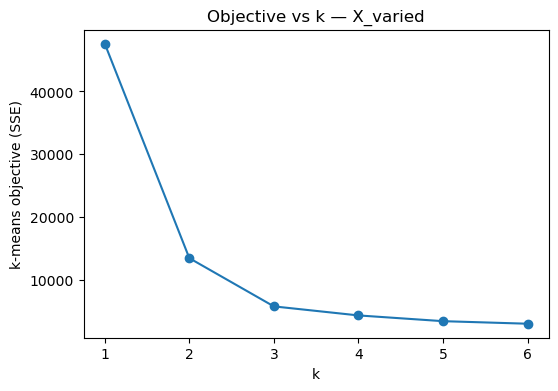

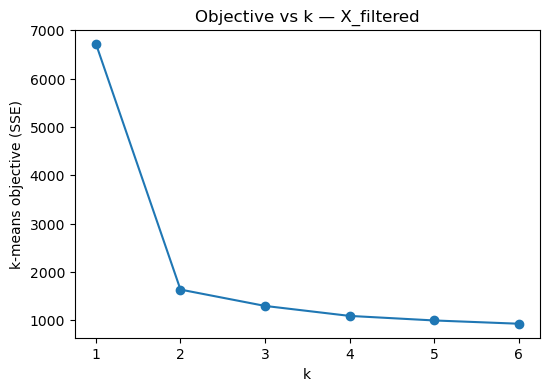

In [6]:
for name, data in datasets.items():
    objectives = []
    for k in ks:
        _, _, obj = kmeans_lloyd(data, k, random_state=random_state)
        objectives.append(obj)

    plt.figure(figsize=(6, 4))
    plt.plot(ks, objectives, marker="o")
    plt.xticks(ks)
    plt.xlabel("k")
    plt.ylabel("k-means objective (SSE)")
    plt.title(f"Objective vs k — {name}")
    plt.show()

###  K-means++ initialization

Explanation of k-means++

Random initialization in standard k-means may place several initial centers very close to each other. As a result, the algorithm can converge to a poor local minimum and produce suboptimal clustering results.

The k-means++ algorithm improves the initialization of cluster centers by spreading them out more evenly over the data space.
In other words, points that are far away from the existing centers have a higher probability of being chosen as new centers. This leads to better initial center placement and typically improves the quality and stability of the final clustering results.

In [7]:
def kmeans_lloyd_pp(X, k, max_iter=200, tol=1e-6, random_state=0):
    """
    Lloyd's algorithm (k-means) with k-means++ initialization.
    Returns: centers (k,d), labels (n,), objective (float)
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    # ---------- k-means++ initialization ----------
    centers = np.empty((k, d), dtype=X.dtype)

    # first center uniformly at random
    idx0 = rng.integers(n)
    centers[0] = X[idx0]

    # squared distance to nearest chosen center
    d2 = ((X - centers[0]) ** 2).sum(axis=1)

    for j in range(1, k):
        total = d2.sum()

        # degenerate case (all points identical)
        if total == 0:
            centers[j] = X[rng.integers(n)]
        else:
            probs = d2 / total
            idx = rng.choice(n, p=probs)
            centers[j] = X[idx]

        # update d2 (distance to nearest center so far)
        new_d2 = ((X - centers[j]) ** 2).sum(axis=1)
        d2 = np.minimum(d2, new_d2)

    # ---------- Lloyd iterations ----------
    labels = None

    for _ in range(max_iter):
        # Assignment step
        dists2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        new_labels = dists2.argmin(axis=1)

        # Update step
        new_centers = centers.copy()
        for j in range(k):
            mask = (new_labels == j)
            if np.any(mask):
                new_centers[j] = X[mask].mean(axis=0)
            else:
                # empty cluster -> reset to a random data point (same rule as Subtask 2)
                new_centers[j] = X[rng.integers(n)]

        # Checking Convergence
        if labels is not None and np.array_equal(new_labels, labels):
            centers, labels = new_centers, new_labels
            break

        shift = np.linalg.norm(new_centers - centers)
        centers, labels = new_centers, new_labels
        if shift < tol:
            break

    # Objective (SSE)
    objective = ((X - centers[labels]) ** 2).sum(axis=1).sum()
    return centers, labels, objective

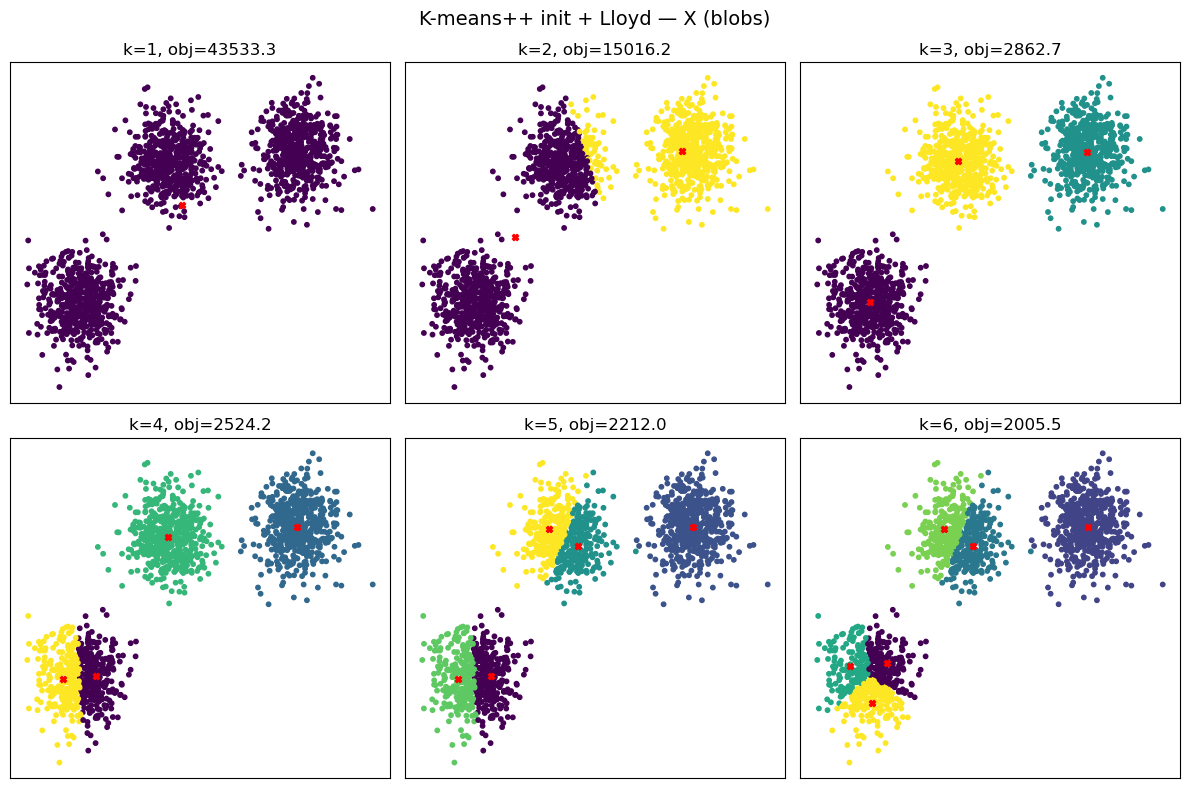

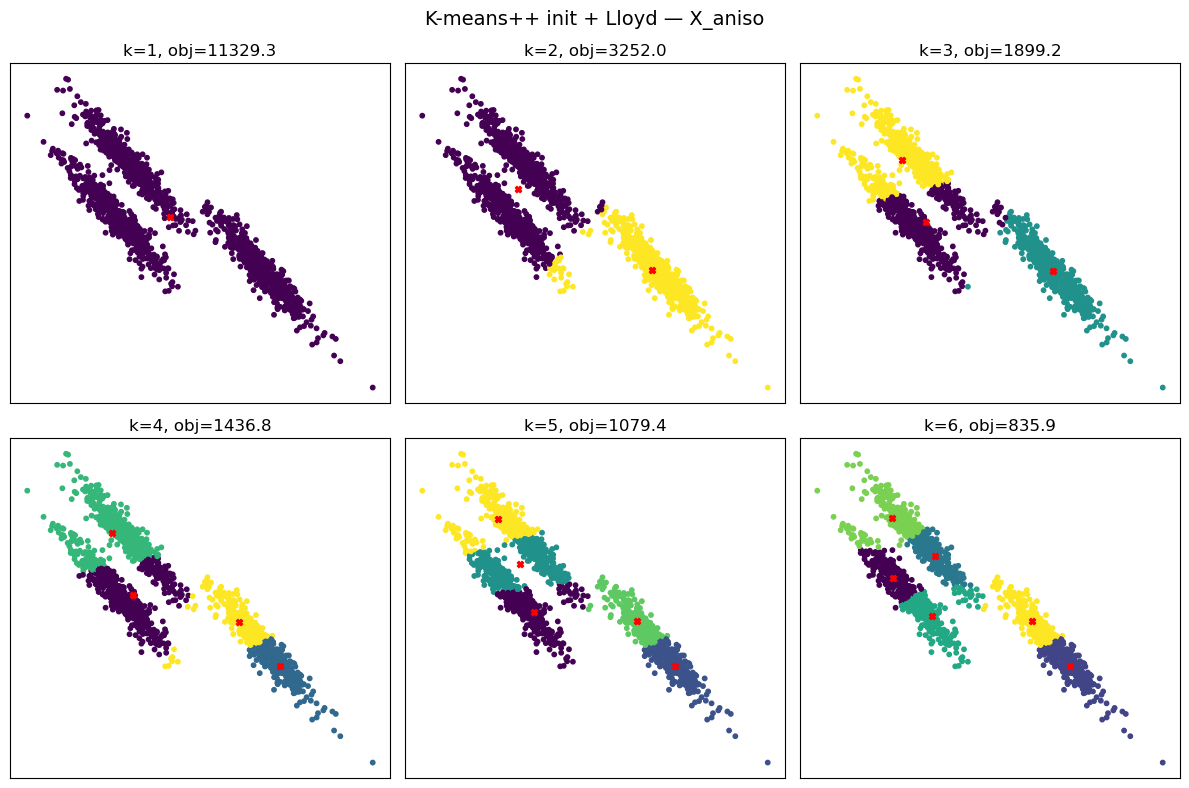

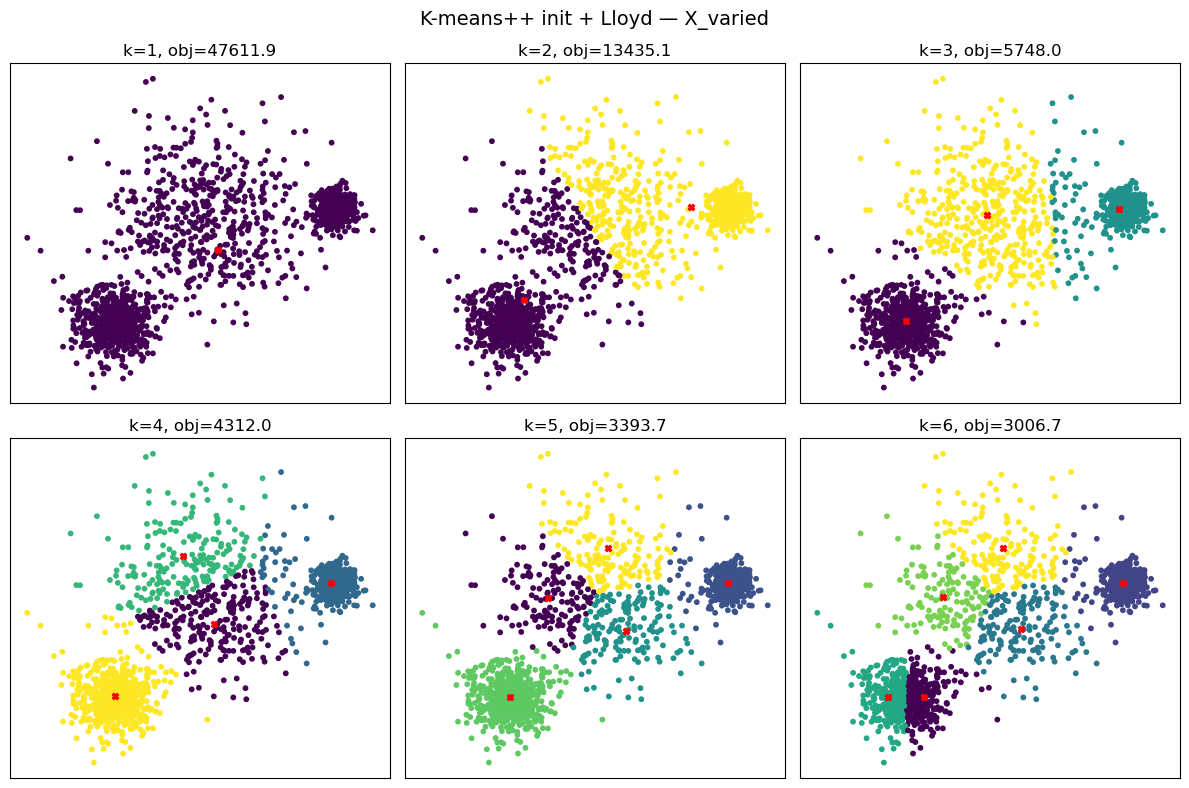

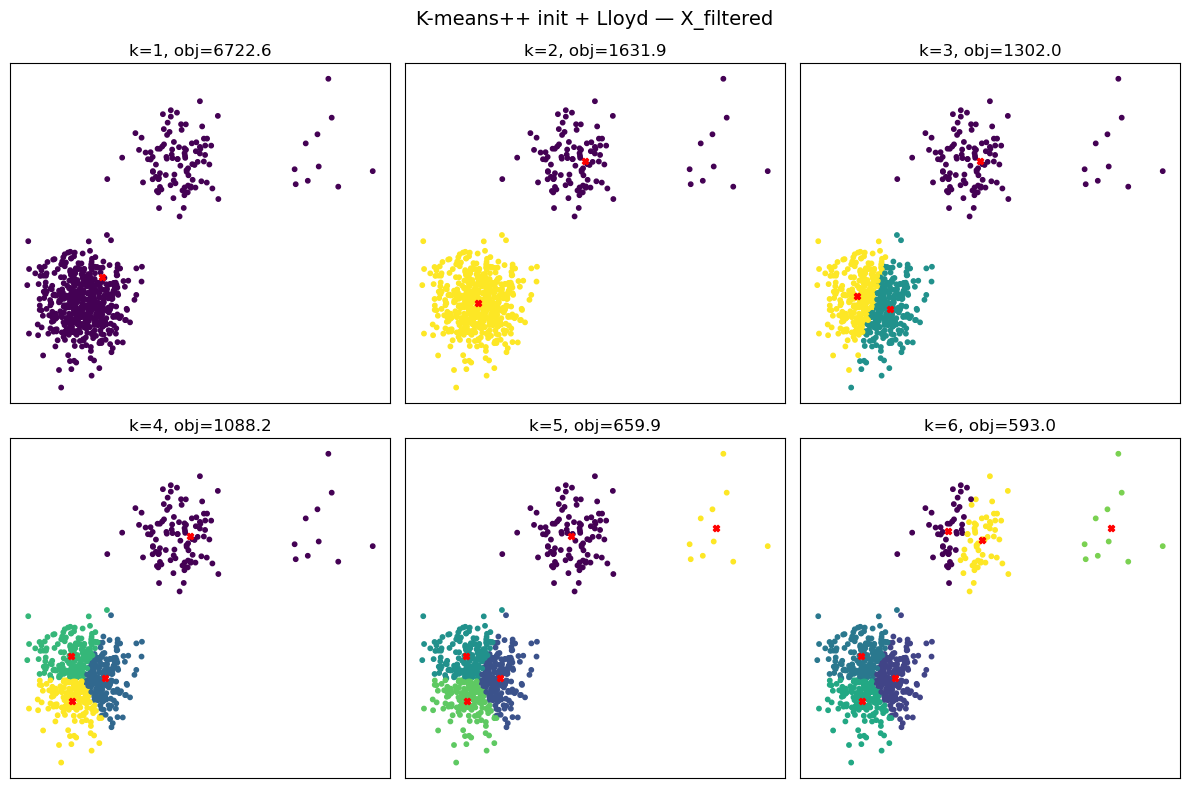

In [8]:
datasets = {
    "X (blobs)": X,
    "X_aniso": X_aniso,
    "X_varied": X_varied,
    "X_filtered": X_filtered
}

ks = [1, 2, 3, 4, 5, 6]
random_state = 0

for name, data in datasets.items():
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for idx, k in enumerate(ks):
        centers, labels, obj = kmeans_lloyd_pp(data, k, random_state=random_state)

        ax = axes[idx]
        ax.scatter(data[:, 0], data[:, 1], c=labels, s=10)
        ax.scatter(centers[:, 0], centers[:, 1], marker="X", s=20, color = 'red')
        ax.set_title(f"k={k}, obj={obj:.1f}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"K-means++ init + Lloyd — {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

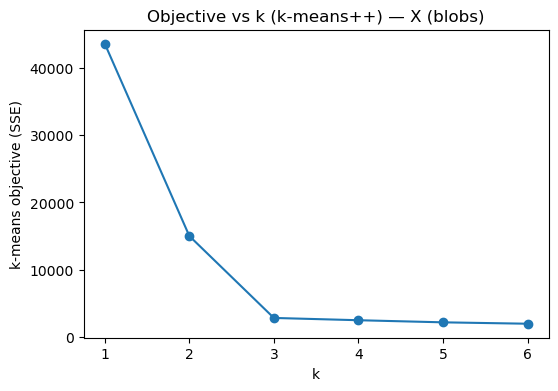

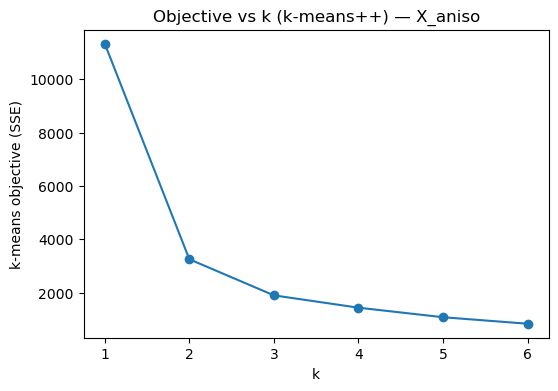

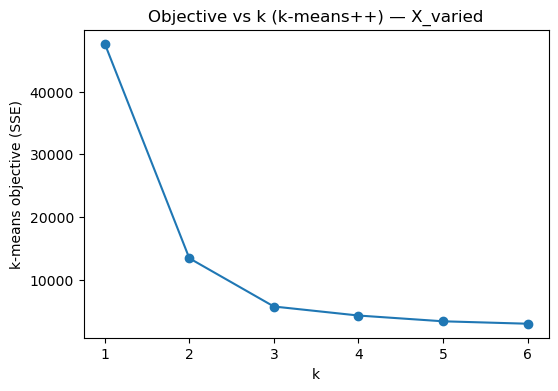

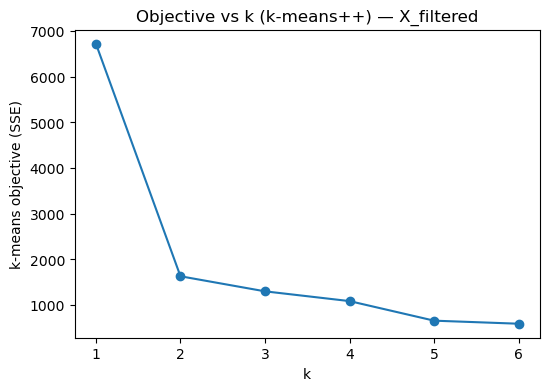

In [9]:
for name, data in datasets.items():
    objectives = []
    for k in ks:
        _, _, obj = kmeans_lloyd_pp(data, k, random_state=random_state)
        objectives.append(obj)

    plt.figure(figsize=(6, 4))
    plt.plot(ks, objectives, marker="o")
    plt.xticks(ks)
    plt.xlabel("k")
    plt.ylabel("k-means objective (SSE)")
    plt.title(f"Objective vs k (k-means++) — {name}")
    plt.show()